# **Aggregated Skin Assessment**

## **Imports**

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
from torchvision import transforms

from transformers import SegformerForSemanticSegmentation

## **Configuration**

In [2]:
WRINKLES_ROOT = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset")
WRINKLES_IMAGES_DIR = WRINKLES_ROOT / "images_wrinkles/images_wrinkles"
WRINKLES_MASKS_DIR = WRINKLES_ROOT / "manual_wrinkle_masks/manual_wrinkle_masks"

WRINKLES_CHECKPOINT_PATH = (
    "/kaggle/input/models/severynpeleshko/wrinkles-detect/pytorch/default/1/"
    "best_segformer_wrinkles.pt"
)
ACNE_CHECKPOINT_PATH = (
    "/kaggle/input/models/severynpeleshko/acne-detect/pytorch/default/1/"
    "best_segformer_acne.pt"
)

SEGFORMER_MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"

IMAGE_SIZE = 1024
BATCH_SIZE = 2
RANDOM_STATE = 42
THRESHOLD = 0.5

ACNE_AREA_WEIGHT = 0.5
ACNE_CONTRAST_WEIGHT = 0.5

WEIGHT_ACNE = 0.50
WEIGHT_WRINKLES = 0.20
WEIGHT_EVENNESS = 0.30

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)

Device: cuda


## **Dataset**

In [3]:
class WrinkleSegDataset(Dataset):
    def __init__(self, pairs, image_size=1024):
        self.pairs = pairs
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST,
        )

        image = self.normalize(TF.to_tensor(image))
        mask = (TF.to_tensor(mask) > 0.5).float()

        return image, mask


def collect_image_mask_pairs(images_dir, masks_dir):
    image_paths = sorted(Path(images_dir).glob("*.png"))
    pairs = []

    for image_path in image_paths:
        mask_path = Path(masks_dir) / image_path.name

        if mask_path.exists():
            pairs.append((image_path, mask_path))
        else:
            print(f"Mask not found for {image_path.name}")

    return pairs


pairs = collect_image_mask_pairs(WRINKLES_IMAGES_DIR, WRINKLES_MASKS_DIR)
print(f"Recovered {len(pairs)} image-mask pairs.")

Recovered 1000 image-mask pairs.


## **Data Loaders**

In [4]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True,
)

test_dataset = WrinkleSegDataset(test_pairs, image_size=IMAGE_SIZE)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("test batches:", len(test_loader))

test batches: 50


## **Model**

In [5]:
class SegFormerBinary(nn.Module):
    def __init__(self, model_name=SEGFORMER_MODEL_NAME, dropout=0.1):
        super().__init__()

        self.model = SegformerForSemanticSegmentation.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True,
        )

        if hasattr(self.model.decode_head, "dropout"):
            self.model.decode_head.dropout.p = dropout

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return logits


def load_segformer_binary(checkpoint_path):
    model = SegFormerBinary(model_name=SEGFORMER_MODEL_NAME, dropout=0.1)
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model


wrinkles_model = load_segformer_binary(WRINKLES_CHECKPOINT_PATH)
acne_model = load_segformer_binary(ACNE_CHECKPOINT_PATH)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


## **Helper Functions**

In [6]:
def denormalize(image, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    image = image.detach().cpu().clone()

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    image = image * std + mean
    return torch.clamp(image, 0, 1)


def preprocess_image(image_path, image_size=(1024, 1024)):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)

    image = np.asarray(image).astype(np.float32) / 255.0
    image = (image - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)

    image = torch.tensor(image).permute(2, 0, 1).float()
    return image.unsqueeze(0)


def to_float_score(value, index=None):
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()

    if isinstance(value, (list, tuple, np.ndarray)):
        return float(value[index])

    return float(value)

## **Severity Scores**

In [7]:
def compute_wrinkle_severity(wrinkles_mask):
    return wrinkles_mask.mean(dim=[1, 2, 3])


def compute_acne_contrast(image, acne_mask):
    image_np = denormalize(image).permute(1, 2, 0).numpy()
    mask_np = acne_mask.detach().cpu().squeeze().numpy().astype(np.uint8)

    if mask_np.sum() == 0:
        return 0.0

    lab = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2LAB)
    a_channel = lab[:, :, 1] / 255.0

    acne_pixels = a_channel[mask_np == 1]

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (61, 61))
    dilated = cv2.dilate(mask_np, kernel)
    healthy_region = (dilated == 1) & (mask_np == 0)
    healthy_pixels = a_channel[healthy_region]

    if len(acne_pixels) == 0 or len(healthy_pixels) == 0:
        return 0.0

    return abs(acne_pixels.mean() - healthy_pixels.mean())


def compute_acne_severity(
    images,
    acne_mask,
    area_weight=ACNE_AREA_WEIGHT,
    contrast_weight=ACNE_CONTRAST_WEIGHT,
):
    area_score = acne_mask.mean(dim=[1, 2, 3])
    scores = []

    for i in range(images.shape[0]):
        contrast_score = compute_acne_contrast(images[i], acne_mask[i])
        score = area_weight * area_score[i].item() + contrast_weight * contrast_score
        scores.append(score)

    return torch.tensor(scores)

## **Overall Score**

In [8]:
def calculate_overall_skin_score(
    s_acne,
    s_wrinkles,
    s_tone,
    s_texture,
    w_a=WEIGHT_ACNE,
    w_w=WEIGHT_WRINKLES,
    w_e=WEIGHT_EVENNESS,
):
    # Overall score in [0, 1], where higher is better.
    # s_acne and s_wrinkles are severity scores, where higher means worse.
    # s_tone and s_texture are evenness scores, where higher means better.
    evenness_penalty = ((1 - s_tone) + (1 - s_texture)) / 2

    score = 1 - (
        w_a * s_acne +
        w_w * s_wrinkles +
        w_e * evenness_penalty
    )

    return float(np.clip(score, 0, 1))


def compute_feature_scores(images, wrinkles_mask, acne_mask):
    s_wrinkles = compute_wrinkle_severity(wrinkles_mask)
    s_acne = compute_acne_severity(images, acne_mask)

    return s_acne, s_wrinkles

## **Prediction**

In [14]:
def predict_skin_features(images):
    with torch.no_grad():
        wrinkles_logits = wrinkles_model(images)
        acne_logits = acne_model(images)

        wrinkles_prob = torch.sigmoid(wrinkles_logits)
        acne_prob = torch.sigmoid(acne_logits)

    wrinkles_mask = (wrinkles_prob > THRESHOLD).float()
    acne_mask = (acne_prob > THRESHOLD).float()

    return wrinkles_mask, acne_mask


batch = next(iter(test_loader))
images = batch[0].to(DEVICE)

wrinkles_mask, acne_mask = predict_skin_features(images)
s_acne, s_wrinkles = compute_feature_scores(images, wrinkles_mask, acne_mask)

for i in range(images.shape[0]):
    print(f"Image {i}")
    print(f"  Acne severity: {s_acne[i].item():.4f}")
    print(f"  Wrinkle severity: {s_wrinkles[i].item():.4f}")

Image 0
  Acne severity: 0.0119
  Wrinkle severity: 0.0074
Image 1
  Acne severity: 0.0054
  Wrinkle severity: 0.0085


## **Segmentation Visualization**

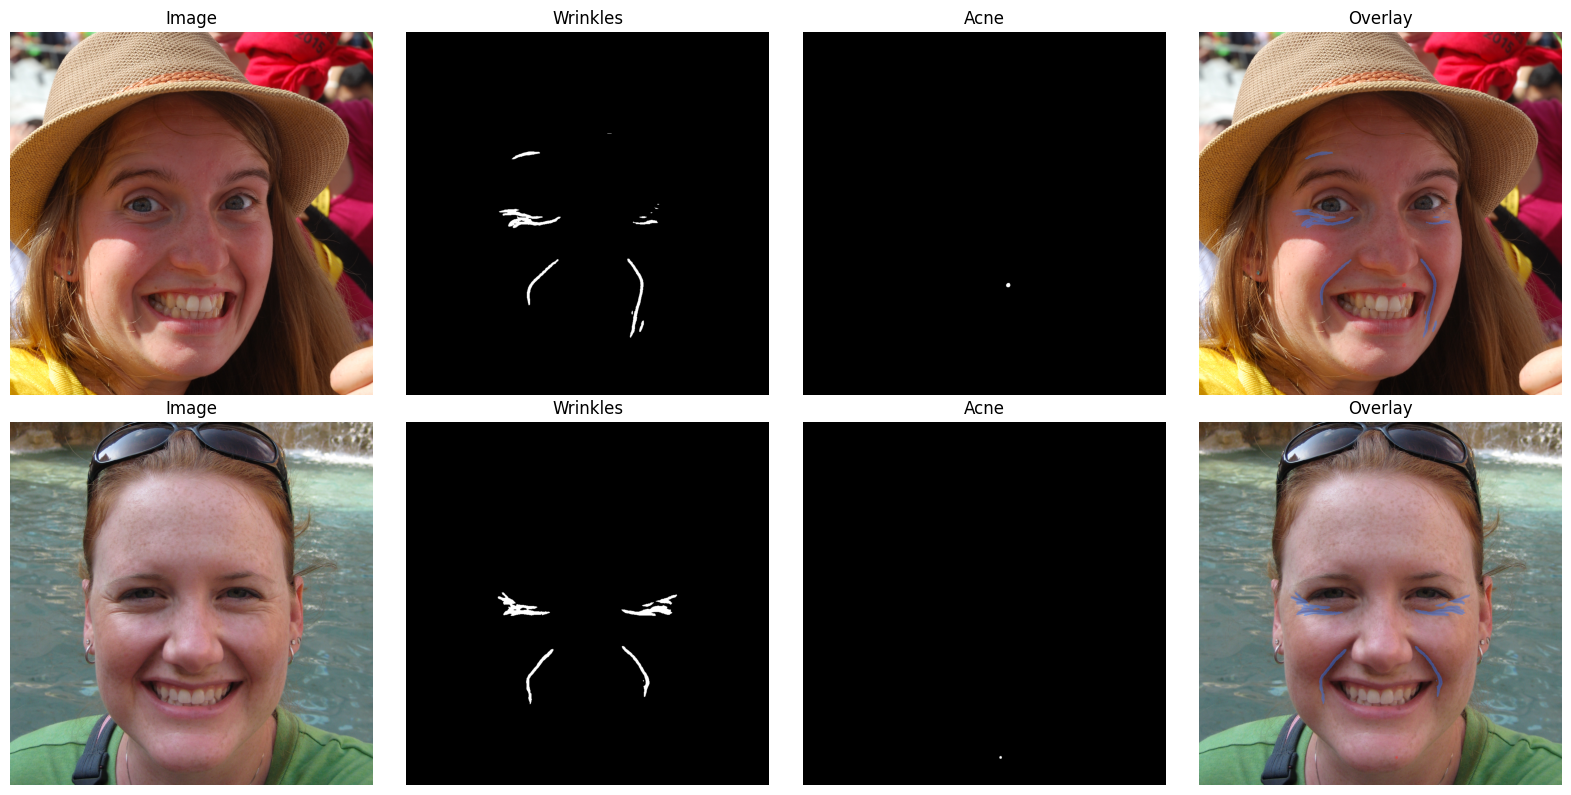

In [15]:
def plot_segmentation_predictions(images, wrinkles_mask, acne_mask, n=4, alpha=0.45):
    images = images.detach().cpu()
    wrinkles_mask = wrinkles_mask.detach().cpu()
    acne_mask = acne_mask.detach().cpu()

    n = min(n, images.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = denormalize(images[i]).permute(1, 2, 0).numpy()
        wrinkle = wrinkles_mask[i].squeeze().numpy()
        acne = acne_mask[i].squeeze().numpy()

        overlay = image.copy()
        acne_bool = acne > 0.5
        wrinkle_bool = wrinkle > 0.5

        overlay[acne_bool] = (1 - alpha) * overlay[acne_bool] + alpha * np.array([1.0, 0.2, 0.2])
        overlay[wrinkle_bool] = (1 - alpha) * overlay[wrinkle_bool] + alpha * np.array([0.2, 0.5, 1.0])

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(wrinkle, cmap="gray")
        axes[i, 1].set_title("Wrinkles")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(acne, cmap="gray")
        axes[i, 2].set_title("Acne")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(np.clip(overlay, 0, 1))
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


plot_segmentation_predictions(images, wrinkles_mask, acne_mask, n=2)

## **Selected Examples**

Image 0
  Acne severity: 0.0119
  Wrinkle severity: 0.0017
Image 1
  Acne severity: 0.0247
  Wrinkle severity: 0.0013
Image 2
  Acne severity: 0.0038
  Wrinkle severity: 0.0121


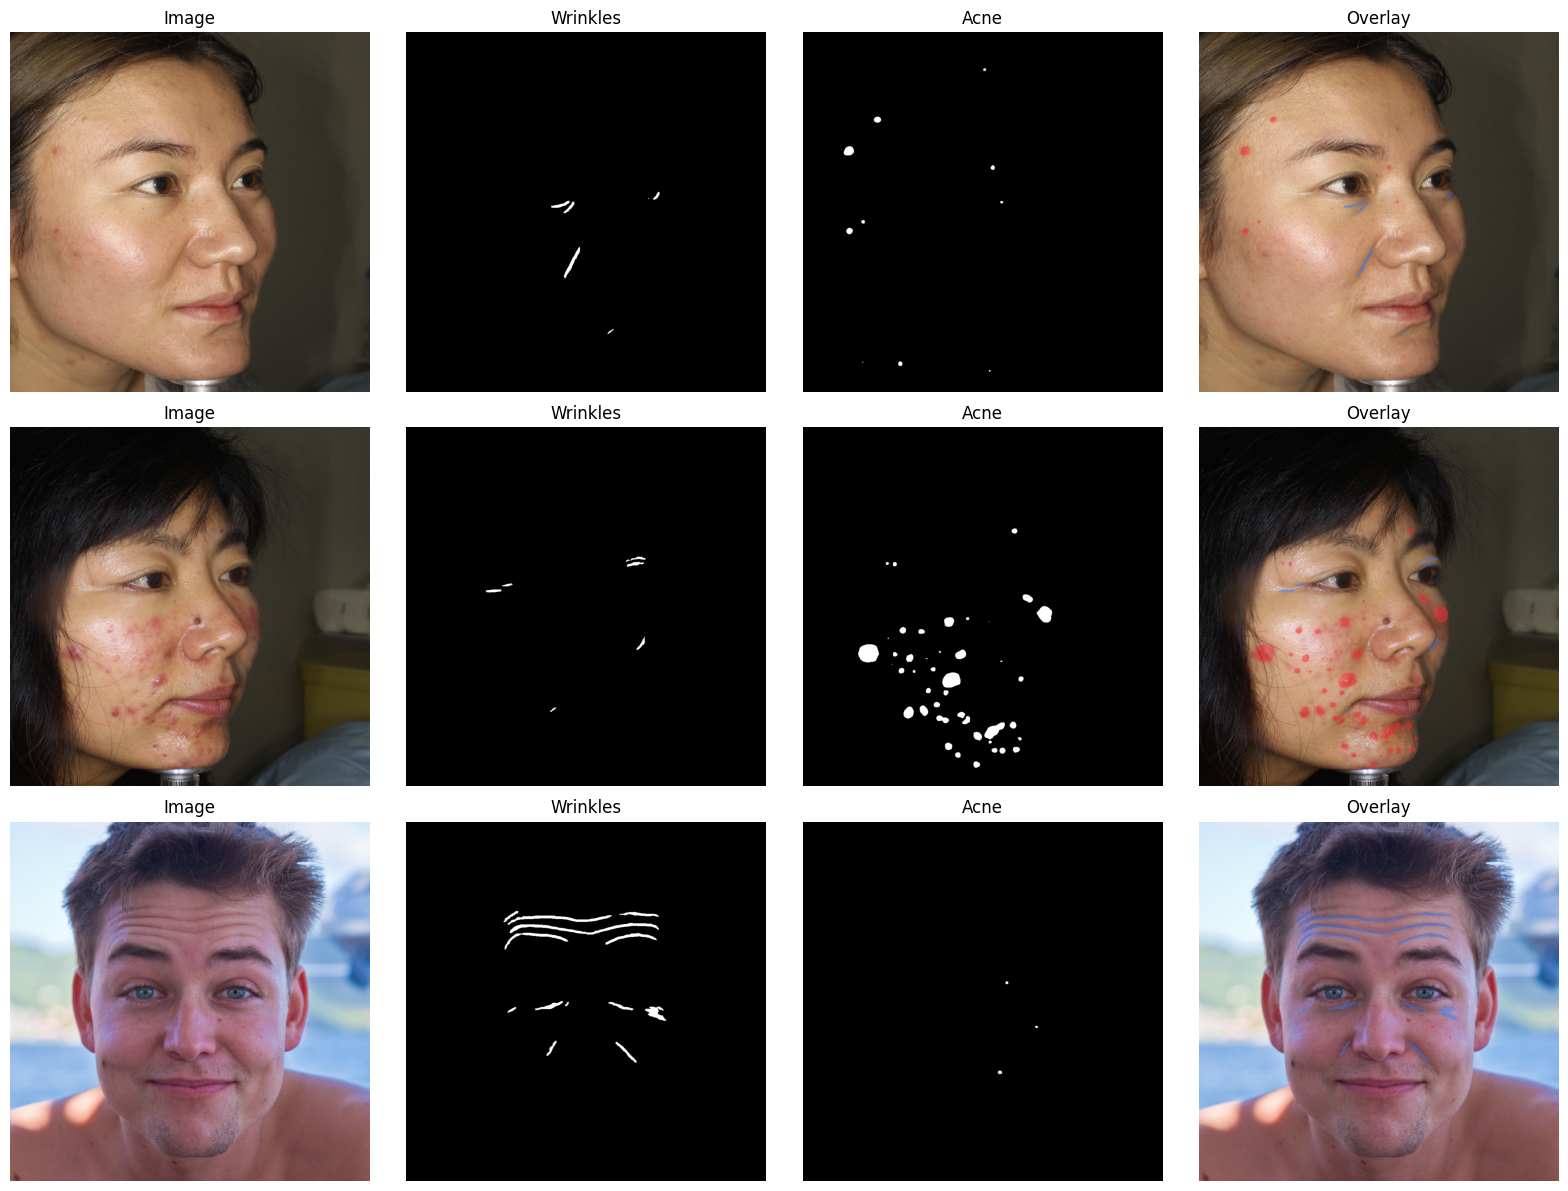

In [16]:
selected_image_paths = [
    "/kaggle/input/datasets/karmagames/acne04-v2/img_data/img_data/levle0_21.jpg",
    "/kaggle/input/datasets/karmagames/acne04-v2/img_data/img_data/levle2_181.jpg",
    "/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00656.png",
]

images = torch.cat(
    [preprocess_image(path, image_size=(IMAGE_SIZE, IMAGE_SIZE)) for path in selected_image_paths],
    dim=0,
).to(DEVICE)

wrinkles_mask, acne_mask = predict_skin_features(images)
s_acne, s_wrinkles = compute_feature_scores(images, wrinkles_mask, acne_mask)

for i in range(images.shape[0]):
    print(f"Image {i}")
    print(f"  Acne severity: {s_acne[i].item():.4f}")
    print(f"  Wrinkle severity: {s_wrinkles[i].item():.4f}")

plot_segmentation_predictions(images, wrinkles_mask, acne_mask, n=3)

## **Final Assessment Visualization**

In [17]:
def plot_skin_assessment(
    images,
    wrinkles_mask,
    acne_mask,
    s_acne,
    s_wrinkles,
    s_tone,
    s_texture,
    n=4,
    w_a=WEIGHT_ACNE,
    w_w=WEIGHT_WRINKLES,
    w_e=WEIGHT_EVENNESS,
    alpha=0.40,
    save_path="skin_assessment.png",
):
    images = images.detach().cpu()
    wrinkles_mask = wrinkles_mask.detach().cpu()
    acne_mask = acne_mask.detach().cpu()

    n = min(n, images.shape[0])

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

    if n == 1:
        axes = [axes]

    for i in range(n):
        ax = axes[i]

        image = denormalize(images[i]).permute(1, 2, 0).numpy()
        image = np.clip(image, 0, 1)

        wrinkle = wrinkles_mask[i].squeeze().numpy() > 0.5
        acne = acne_mask[i].squeeze().numpy() > 0.5

        acne_score = to_float_score(s_acne, i)
        wrinkles_score = to_float_score(s_wrinkles, i)
        tone_score = to_float_score(s_tone, i)
        texture_score = to_float_score(s_texture, i)

        overall_score = calculate_overall_skin_score(
            s_acne=acne_score,
            s_wrinkles=wrinkles_score,
            s_tone=tone_score,
            s_texture=texture_score,
            w_a=w_a,
            w_w=w_w,
            w_e=w_e,
        )

        overlay = image.copy()

        acne_color = np.array([1.0, 0.2, 0.2])
        wrinkle_color = np.array([0.2, 0.5, 1.0])

        overlay[acne] = (1 - alpha) * overlay[acne] + alpha * acne_color
        overlay[wrinkle] = (1 - alpha) * overlay[wrinkle] + alpha * wrinkle_color

        both = acne & wrinkle
        overlay[both] = (1 - alpha) * overlay[both] + alpha * np.array([0.7, 0.2, 0.7])

        ax.imshow(np.clip(overlay, 0, 1))
        ax.axis("off")

        ax.set_title(
            f"Overall: {overall_score:.3f}",
            fontsize=14,
            fontweight="bold",
        )

        ax.text(
            0.5,
            -0.08,
            f"Acne: {acne_score:.3f} | Wrinkles: {wrinkles_score:.3f}\n"
            f"Tone: {tone_score:.3f} | Texture: {texture_score:.3f}",
            transform=ax.transAxes,
            ha="center",
            fontsize=10,
        )

        score_color = plt.cm.RdYlGn(overall_score)
        ax.add_patch(
            plt.Rectangle(
                (0, 0),
                1,
                0.05,
                transform=ax.transAxes,
                color=score_color,
                clip_on=False,
            )
        )

    legend_elements = [
        Patch(facecolor=[1.0, 0.2, 0.2], label="Acne"),
        Patch(facecolor=[0.2, 0.5, 1.0], label="Wrinkles"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=11,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## **Assessment Scores**

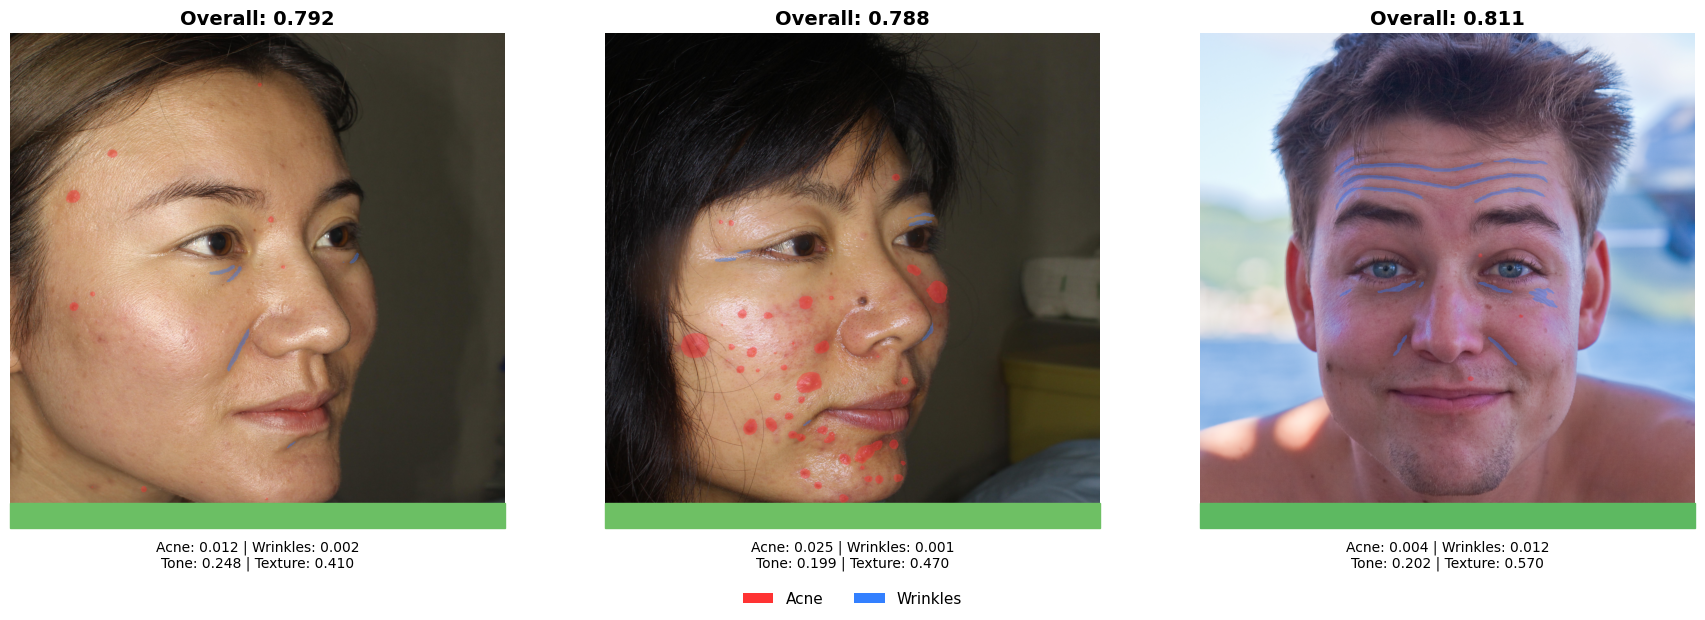

In [18]:
# These scores are computed externally using the tone and texture evenness notebooks.
s_tone = [0.248, 0.199, 0.202]
s_texture = [0.41, 0.47, 0.57]

plot_skin_assessment(
    images=images,
    wrinkles_mask=wrinkles_mask,
    acne_mask=acne_mask,
    s_acne=s_acne,
    s_wrinkles=s_wrinkles,
    s_tone=s_tone,
    s_texture=s_texture,
    n=3,
)